In [45]:
sample_data = {
    'constant': 1,
    'terms': [
        {'vars': [0], 'coef': 1},
        # {'vars': [1, 2], 'coef': -2},
        {'vars': [1, 2, 3], 'coef': -1.8},
    ]
}

In [46]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate, grover_operator, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.quantum_info import hellinger_fidelity
import matplotlib.pyplot as plt
import random
import numpy as np

In [47]:
class GroverAdaptiveSearch:
    """
        Grover Adaptive Search (GAS) implementation for Higher-Order Unconstrained Binary Optimization (HUBO).
        Main reference: https://doi.org/10.1109/TCOMM.2023.3244924

        Attributes:
            n (int): Number of binary variables.
            m (int): Number of qubits for representing the objective function.
            hubo (dict): HUBO formulation of the problem.
    """
    def __init__(self, n, m, hubo):
        self.n = n
        self.m = m
        self.hubo = hubo
        self.qc = QuantumCircuit(n+m)
        self.backend = AerSimulator()

        # GAS setup
        self.i = 0
        self.k = 1
        self.b = [random.randint(0, 1) for _ in range(self.n)]
        self.y = self.hubo['constant']

        # Evaluate objective function
        for term in self.hubo['terms']:
            res = term['coef']
            for var in term['vars']:
                res *= self.b[var]
            self.y += res

        self.L = random.randint(0, self.k)
        self.L_prev = None
        self.lambda_ = 8/7

        # Fidelity and QFIM calculation
        self.previous_counts = None
    
    def build_A_y_i(self):
        A_y_i = QuantumCircuit(self.n + self.m, name='A_y_i')
        A_y_i.h(range(self.n + self.m))

        # encode constant
        encode_qc = QuantumCircuit(self.m, name=f"U_G({self.hubo['constant']} pi/{2**(self.m-1)})")
        angle = 2 * np.pi * (self.hubo['constant'] - self.y) / 2 ** self.m
        for j in range(self.m):
            factor = 2 ** j
            encode_qc.p(factor * angle, j)
        encode_gate = encode_qc.to_gate()
        A_y_i.append(encode_gate, range(self.n, self.n+self.m))

        # encode terms
        for term in self.hubo['terms']:
            encode_qc = QuantumCircuit(self.m, name=f"U_G({term['coef']} pi/{2**(self.m-1)})")
            angle = 2 * term['coef'] * np.pi / 2 ** self.m
            for j in range(self.m):
                factor = 2 ** j
                encode_qc.p(factor * angle, j)
            encode_gate = encode_qc.to_gate().control(len(term['vars']))
            A_y_i.append(encode_gate, term['vars'] + list(range(self.n, self.n+self.m)))

        # IQFT
        iqft = QFTGate(self.m).inverse()
        A_y_i.append(iqft, range(self.n, self.n+self.m))
        
        return A_y_i

    def build_D_n(self):
        D_n = QuantumCircuit(self.n, name='D_n')
        D_n.h(range(self.n))
        D_n.x(range(self.n))
        # Multi-controlled phase gate to flip the target state
        D_n.mcp(np.pi, list(range(self.n - 1)), self.n - 1)
        D_n.x(range(self.n))
        D_n.h(range(self.n))
        return D_n

    def build_G(self):
        G = QuantumCircuit(self.n + self.m, name='G')
        
        # 1. Oracle (Flip phase of negative states using the MSB of register m)
        G.z(self.n + self.m - 1)
        
        # 2. Uncompute State Preparation
        G.append(self.build_A_y_i().inverse(), range(self.n + self.m))
        
        # 3. Diffuse ONLY the n variable qubits
        # This automatically builds the H^(tensor n) -> (2|0><0| - I) -> H^(tensor n) chain
        diffusion_gate = grover_operator(oracle=QuantumCircuit(self.n)).to_gate()
        G.append(diffusion_gate, range(self.n)) # Tied strictly to the n register
        
        # 4. Re-compute State Preparation
        G.append(self.build_A_y_i(), range(self.n + self.m))
        
        return G

    def build(self):
        self.qc = QuantumCircuit(self.n + self.m)
        
        self.qc.append(self.build_A_y_i(), range(self.n + self.m))
        for i in range(self.L):
            self.qc.append(self.build_G(), range(self.n + self.m))

        self.qc.measure_all()

    def run(self, shots=1000):
        compiled_qc = transpile(self.qc, self.backend)
        job = self.backend.run(compiled_qc, shots=shots)
        counts = job.result().get_counts()
        most_frequent_state = max(counts, key=counts.get)
        clean_state = most_frequent_state.replace(" ", "")
        measured_b_str = clean_state[-self.n:]
        new_b = [int(bit) for bit in measured_b_str]
        
        # Calculate true objective value classically
        new_y = self.hubo['constant']
        for term in self.hubo['terms']:
            res = term['coef']
            for var in term['vars']:
                res *= new_b[var]
            new_y += res
            
        return new_b, new_y, counts

    def optimize(self, max_iter=20, shots=1024, verbose=True):
        """
        Executes the main loops of GAS until convergence or max_iter is hit.
        """
        if verbose:
            print(f"Starting GAS. Initial Threshold (y_0): {self.y} | State: {self.b}")
            print("-" * 60)

        history = {
            "iteration" : [],
            "hellinger_fidelity_wrt_previous" : [],
            "approximate_qfim": []
        }

        for iteration in range(max_iter):
            self.i = iteration
            
            # Step 1: Reassemble the circuit using the current loop parameters
            self.build()
            
            # Step 2: Sample from the quantum simulator
            candidate_b, candidate_y, candidate_current_counts = self.run(shots=shots)
            
            # Step 2.5: QFIM calculation
            dL = abs(self.L - self.L_prev) if (hasattr(self, 'L_prev') and self.L_prev is not None) else 0

            if self.previous_counts is not None and dL > 0:
                h_fid = hellinger_fidelity(candidate_current_counts, self.previous_counts)
                # Equation (1) from: 
                # https://quantumcomputing.stackexchange.com/questions/44297/infinitesimal-trace-distance-and-metric#:~:text=With%20this%20infinitesimal%20change%2C%20the,a%2F29716%2F15820).
                # In short:
                # (1)    Fidelity(phi, phi+dL) = 1 - Fisher(phi_dL) * dL^2 / 4
                # (2)  4(1 - Fid(phi, phi+dL)) = Fisher(phi_dL) * dL^2
                # Resulting in (3) below
                fim_val = 4 * (1 - h_fid) / (dL ** 2)
            else:
                h_fid = 1.0  # Baseline for the first iteration
                fim_val = 0

            history['iteration'].append(iteration)
            history['hellinger_fidelity_wrt_previous'].append(h_fid)
            history['approximate_qfim'].append(fim_val)
            
            # Keep a historical reference to this classical shot outcome distribution
            self.previous_counts = candidate_current_counts
            self.L_prev = self.L
            # Step 3: Adaptive Update Rules (Step 6 of paper pseudocode)
            if candidate_y < self.y:
                if verbose:
                    print(f"Iteration {self.i:02d}: IMPROVEMENT FOUND!")
                    print(f"  Old Threshold: {self.y} -> New Threshold: {candidate_y}")
                    print(f"  Config: {candidate_b} | Grover Steps (L) Used: {self.L}")
                
                # Update baseline parameters
                self.b = candidate_b
                self.y = candidate_y
                self.k = 1  # Reset step parameter on success
            else:
                # No improvement found: widen the random exploration step range
                # Cap the growth of k at roughly 2^(n/2) to prevent exponential exploration overhead
                self.k = min(self.lambda_ * self.k, int(2**(self.n / 2)) + 1)
                if verbose:
                    print(f"Iteration {self.i:02d}: No improvement. Expanding search range (k={self.k:.2f})")
            
            # Choose a new random number of Grover iterations for the next cycle
            self.L = random.randint(0, int(self.k))
            
        if verbose:
            print("-" * 60)
            print(f"Optimization Finished. Global Minimum found: {self.y} at configuration {self.b}\nHistory:\n- Hellinger: {history['hellinger_fidelity_wrt_previous']}\n- Approx. QFIM: {history['approximate_qfim']}")
            
        return self.b, self.y, history

In [48]:
def plot_gas_geometry(history):
    """
    Plots Hellinger Fidelity and Approximated QFIM/FIM across GAS iterations.
    """
    iterations = history['iteration']
    fidelity = history['hellinger_fidelity_wrt_previous']
    fim = history['approximate_qfim']
    
    # Create the figure and the first (left) axis
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # Plot Hellinger Fidelity on the left axis
    color1 = '#1f77b4'
    ax1.set_xlabel('GAS Optimization Iteration', fontweight='bold', labelpad=10)
    ax1.set_ylabel('Hellinger Fidelity (Overlap)', color=color1, fontweight='bold')
    line1 = ax1.plot(iterations, fidelity, color=color1, marker='o', linewidth=2, label='Hellinger Fidelity')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_ylim(-0.05, 1.05) # Fidelity is strictly bound between 0 and 1
    
    # Create a second axis that shares the same x-axis
    ax2 = ax1.twinx()  
    
    # Plot Approximated FIM on the right axis
    color2 = '#d62728' # Deep Red
    ax2.set_ylabel('Approximated QFIM', color=color2, fontweight='bold')
    line2 = ax2.plot(iterations, fim, color=color2, marker='s', linestyle='--', linewidth=2, label='Approximated FIM')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)
    
    plt.title('Quantum State Geometry Landscape in Grover Adaptive Search', fontweight='bold', fontsize=14, pad=15)
    fig.tight_layout() 
    plt.show()

Starting GAS. Initial Threshold (y_0): 1.0 | State: [0, 1, 0, 0]
------------------------------------------------------------
Iteration 00: No improvement. Expanding search range (k=1.14)
Iteration 01: No improvement. Expanding search range (k=1.31)
Iteration 02: No improvement. Expanding search range (k=1.49)
Iteration 03: No improvement. Expanding search range (k=1.71)
Iteration 04: No improvement. Expanding search range (k=1.95)
Iteration 05: No improvement. Expanding search range (k=2.23)
Iteration 06: No improvement. Expanding search range (k=2.55)
Iteration 07: No improvement. Expanding search range (k=2.91)
Iteration 08: No improvement. Expanding search range (k=3.33)
Iteration 09: No improvement. Expanding search range (k=3.80)
Iteration 10: No improvement. Expanding search range (k=4.34)
Iteration 11: No improvement. Expanding search range (k=4.96)
Iteration 12: No improvement. Expanding search range (k=5.00)
Iteration 13: No improvement. Expanding search range (k=5.00)
Iterat

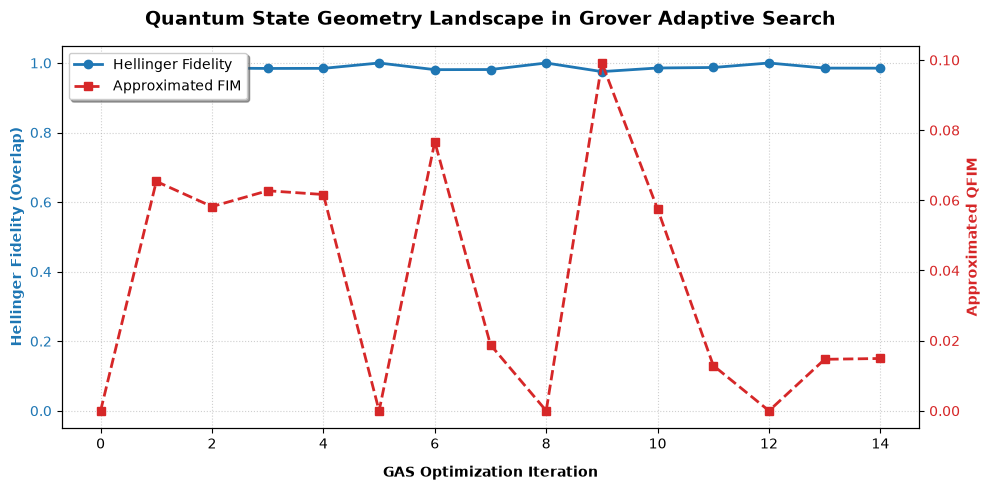

In [49]:
n = 4
m = 3
hubo = sample_data
GAS = GroverAdaptiveSearch(n, m, hubo)
best_config, minimum_energy, history = GAS.optimize(max_iter=15)
plot_gas_geometry(history)

In [50]:
def preprocess_hubo_for_direct_encoding(raw_hubo, m):
    """
    Normalizes a real-valued HUBO problem to safely fit inside the phase bounds 
    of an m-qubit register, protecting against phase wrapping.
    
    Parameters:
        raw_hubo (dict): The original dictionary with 'constant' and 'terms'.
        m (int): Number of evaluation qubits you intend to use.
        
    Returns:
        dict: A scaled HUBO ready for the unmodified GAS implementation.
        float: The scale factor applied (needed to convert final energies back).
    """
    # 1. Calculate the absolute worst-case maximum energy bound
    max_energy_bound = abs(raw_hubo['constant']) + sum(abs(t['coef']) for t in raw_hubo['terms'])
    
    # 2. Calculate the maximum value a continuous two's complement register can hold
    # We use 2**(m-1) to preserve the negative/positive sign split boundary
    max_register_value = 2 ** (m - 1)
    
    # 3. Create our global scaling factor
    # Leave a tiny 1% safety margin to prevent boundary rounding issues
    scale_factor = (max_register_value / max_energy_bound) * 0.99
    
    # 4. Deep copy the dictionary structure so we don't mutate your original data
    processed_hubo = copy.deepcopy(raw_hubo)
    
    # 5. Apply the scale factor uniformly to all coefficients
    processed_hubo['constant'] *= scale_factor
    for term in processed_hubo['terms']:
        term['coef'] *= scale_factor
        
    return processed_hubo, scale_factor

In [51]:
import json
import ast
import copy

with open('sample2.json', 'r', encoding='utf-8') as file:
    data = json.load(file)[0]

n = data['num_variables']
m = 20
hubo = ast.literal_eval(data['objective_json'])
scaled_hubo, scale_factor = preprocess_hubo_for_direct_encoding(hubo, m)
print(f'Scaled HUBO by {scale_factor}')

Scaled HUBO by 5.684471074047787e-06


In [52]:
GAS = GroverAdaptiveSearch(n, m, scaled_hubo)
best_config, minimum_energy = GAS.optimize(max_iter=15)

Starting GAS. Initial Threshold (y_0): -373.6243692518642 | State: [0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]
------------------------------------------------------------


CircuitTooWideForTarget: 'Number of qubits (59) in circuit-185871 is greater than maximum (30) in the coupling_map'